# Business Understanding

## Project Domain

  Dalam dunia kerja yang kompetitif, memahami faktor-faktor yang memengaruhi gaji seseorang sangat penting bagi perusahaan maupun pencari kerja. Dataset ini mencakup informasi seperti pendidikan, pengalaman kerja, industri, usia, dan jenis kelamin, yang dapat digunakan untuk membangun model prediksi gaji yang lebih objektif dan berdasarkan data.



## Problem Statements

* Banyak organisasi mengalami kesulitan dalam menentukan gaji yang kompetitif dan adil bagi karyawan, terutama dalam proses perekrutan.

* Tidak adanya sistem prediksi gaji berbasis data seringkali mengakibatkan penawaran gaji yang tidak sebanding dengan kualifikasi calon karyawan.

* Calon karyawan juga kesulitan memperkirakan gaji yang pantas untuk mereka ajukan berdasarkan latar belakang dan pengalaman mereka.

## Goals

* Menganalisis faktor-faktor utama yang memengaruhi besaran gaji, seperti pendidikan, pengalaman, jenis kelamin, dan industri.

* Membangun model prediksi gaji berbasis machine learning yang dapat memberikan estimasi gaji akurat untuk kandidat berdasarkan input profil mereka.

* Memberikan wawasan yang dapat digunakan perusahaan untuk menyusun kebijakan kompensasi yang lebih adil dan data-driven.

## Solution Statements

* Melakukan eksplorasi data dan analisis statistik untuk memahami distribusi dan korelasi antara variabel.

* Mengembangkan model prediksi menggunakan algoritma machine learning seperti regresi linier, Random Forest, atau jaringan saraf buatan (ANN).

* Mengevaluasi performa model menggunakan metrik seperti MAE, MSE, dan R² score.

* Menyediakan antarmuka sederhana (misalnya dengan Streamlit) agar pengguna dapat memasukkan informasi profil dan mendapatkan estimasi gaji secara langsung.

# Data Understanding

## Import data dari kaggle

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"kukuhvalfaldi","key":"48b9866808861259469e3bd660e3d290"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [3]:
!kaggle datasets download -d mrsimple07/salary-prediction-data

Dataset URL: https://www.kaggle.com/datasets/mrsimple07/salary-prediction-data
License(s): apache-2.0


In [4]:
!mkdir salaly-prediction-for-beginer
!kaggle datasets download -d mrsimple07/salary-prediction-data -p salaly-prediction-for-beginer
!unzip salaly-prediction-for-beginer/*.zip -d salaly-prediction-for-beginer
!ls salaly-prediction-for-beginer

Dataset URL: https://www.kaggle.com/datasets/mrsimple07/salary-prediction-data
License(s): apache-2.0
Archive:  salaly-prediction-for-beginer/salary-prediction-data.zip
  inflating: salaly-prediction-for-beginer/salary_prediction_data.csv  
salary_prediction_data.csv  salary-prediction-data.zip


## Import Library yang dibutuhkan

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [6]:
df = pd.read_csv("salaly-prediction-for-beginer/salary_prediction_data.csv")

## Exploratory Data Analysis

In [7]:
df.head()

,Education,Experience,Location,Job_Title,Age,Gender,Salary
0,High School,8,Urban,Manager,63,Male,84620.053665
1,PhD,11,Suburban,Director,59,Male,142591.255894
2,Bachelor,28,Suburban,Manager,61,Female,97800.255404
3,High School,29,Rural,Director,45,Male,96834.671282
4,PhD,25,Urban,Analyst,26,Female,132157.786175


In [8]:
df.shape

(1000, 7)

In [9]:
df.dtypes

,0
Education,object
Experience,int64
Location,object
Job_Title,object
Age,int64
Gender,object
Salary,float64


In [10]:
df.isnull().sum()

,0
Education,0
Experience,0
Location,0
Job_Title,0
Age,0
Gender,0
Salary,0


In [11]:
df.describe()

,Experience,Age,Salary
count,1000.000000,1000.000000,1000.000000
mean,14.771000,42.377000,105558.404239
std,8.341111,13.609412,28256.972075
min,1.000000,20.000000,33510.510669
25%,7.000000,30.000000,85032.141517
50%,15.000000,43.000000,104314.518315
75%,22.000000,55.000000,126804.047524
max,29.000000,64.000000,193016.602150


In [12]:
for column in df.columns:
    print(f"{column} unique values: {df[column].nunique()}")

Education unique values: 4
Experience unique values: 29
Location unique values: 3
Job_Title unique values: 4
Age unique values: 45
Gender unique values: 2
Salary unique values: 1000


In [13]:
df['Education'].value_counts()
df['Job_Title'].value_counts()
df['Gender'].value_counts()

,count
Gender,
Male,516
Female,484


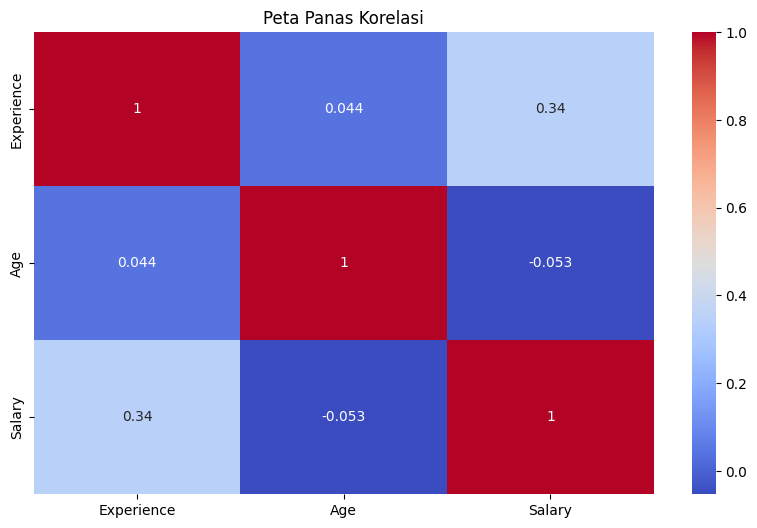

In [14]:
# Peta Panas Korelasi
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Peta Panas Korelasi")
plt.show()

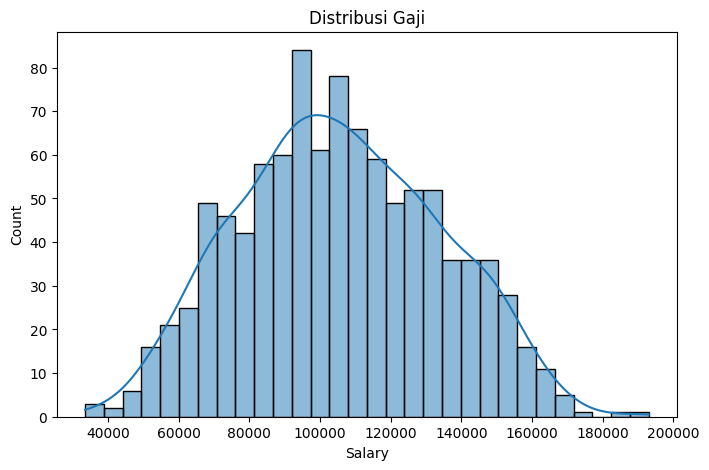

In [15]:
# Distribusi Gaji
plt.figure(figsize=(8,5))
sns.histplot(df['Salary'], bins=30, kde=True)
plt.title("Distribusi Gaji")
plt.show()

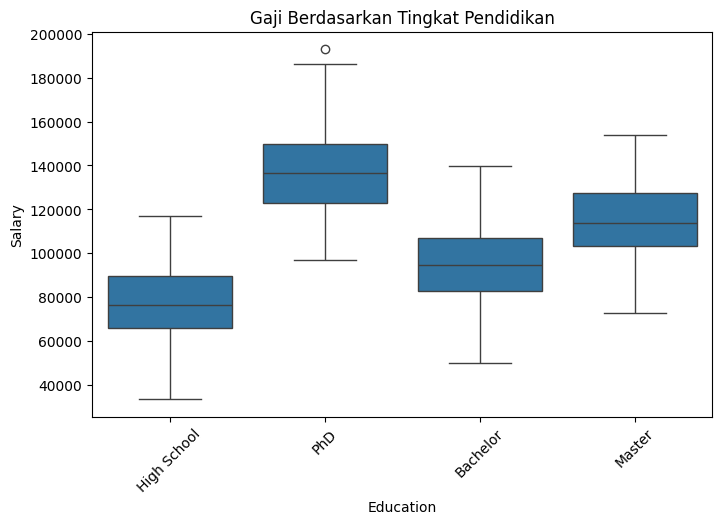

In [16]:
# Gaji Berdasarkan Tingkat Pendidikan
plt.figure(figsize=(8,5))
sns.boxplot(x='Education', y='Salary', data=df)
plt.xticks(rotation=45)
plt.title("Gaji Berdasarkan Tingkat Pendidikan")
plt.show()

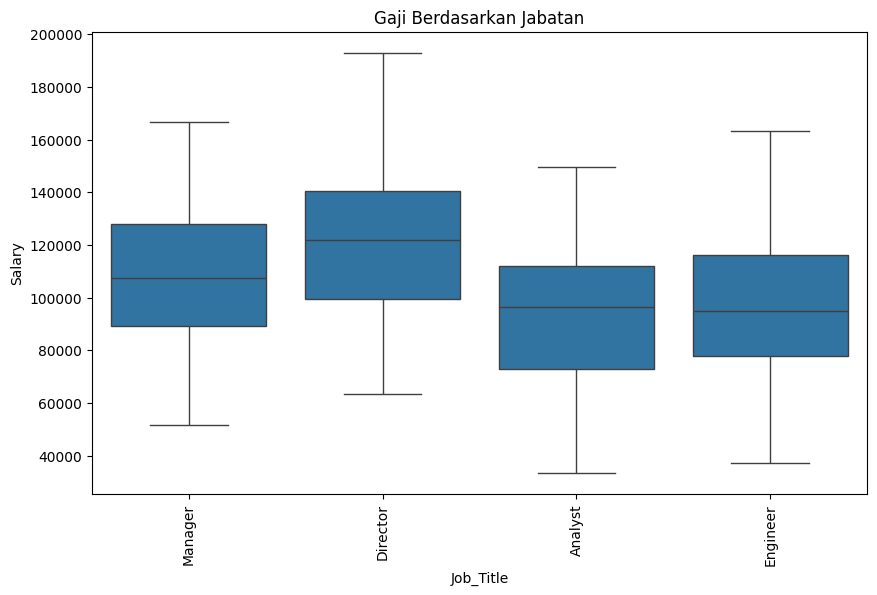

In [17]:
# Gaji Berdasarkan Jabatan
plt.figure(figsize=(10,6))
sns.boxplot(x='Job_Title', y='Salary', data=df)
plt.xticks(rotation=90)
plt.title("Gaji Berdasarkan Jabatan")
plt.show()

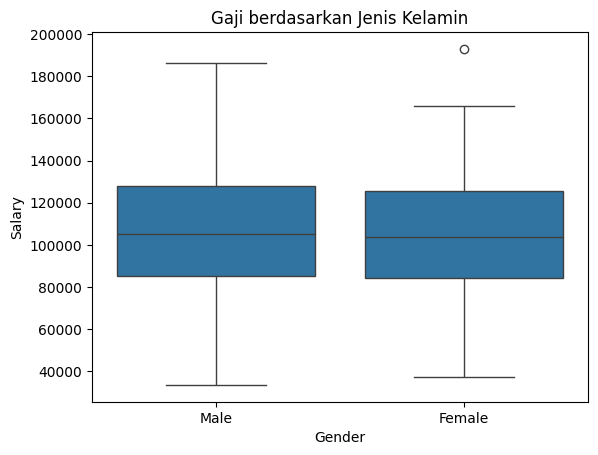

In [18]:
# Jenis Kelamin vs Gaji
sns.boxplot(x='Gender', y='Salary', data=df)
plt.title("Gaji berdasarkan Jenis Kelamin")
plt.show()

# Data Preparation

In [19]:
# Mengkode Kolom Kategoris
le = LabelEncoder()
df['Education'] = le.fit_transform(df['Education'])
df['Job_Title'] = le.fit_transform(df['Job_Title'])
df['Gender'] = le.fit_transform(df['Gender'])
df['Location'] = le.fit_transform(df['Location'])

In [20]:
# Fitur dan Sasaran
X = df.drop("Salary", axis=1)
y = df["Salary"]

In [21]:
# Fitur Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [562]:
# Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Modeling

In [569]:
# ANN Model
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [570]:
model.compile(optimizer='adam', loss='mse')

In [646]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, verbose=1)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - loss: 119533216.0000 - val_loss: 115471824.0000
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - loss: 119014720.0000 - val_loss: 115042960.0000
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 112617048.0000 - val_loss: 114614960.0000
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 120530424.0000 - val_loss: 114186736.0000
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 117705896.0000 - val_loss: 113773872.0000
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 109032888.0000 - val_loss: 113355568.0000
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 112745032.0000 - val_loss: 112919856.0000
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 108208864.0000 - val_loss: 112474728.0000
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 106590440.0000 - val_loss: 112013184.0000
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 105610192.0000 - val_loss: 111537640.

# Evaluation

In [647]:
# Memprediksi
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


In [648]:
# Metrik
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [649]:
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R2 Score: {r2}")

Mean Squared Error: 76768752.0
Root Mean Squared Error: 8761.777901773132
R2 Score: 0.9386340975761414


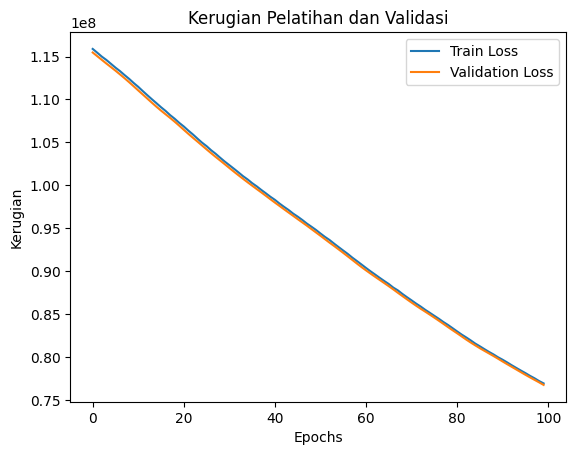

In [650]:
# Plot Kurva Kerugian
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Kerugian Pelatihan dan Validasi')
plt.xlabel('Epochs')
plt.ylabel('Kerugian')
plt.legend()
plt.show()

# Deployment

## Model Simulation

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 376ms/step - loss: 9979729920.0000 - val_loss: 8994976768.0000
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 10135964672.0000 - val_loss: 8994963456.0000
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 10063814656.0000 - val_loss: 8994950144.0000
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 9575779328.0000 - val_loss: 8994936832.0000
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 9777329152.0000 - val_loss: 8994924544.0000
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 9933566976.0000 - val_loss: 8994911232.0000
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 9725218816.0000 - val_loss: 8994898944.0000
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 9842652160.0000 - val_loss: 8994885632.0000
Epoch 9/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 9757743104.0000 - val_loss: 8994872320.0000
Epoch 10/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 9972833280.0000 - val_loss: 8994859008

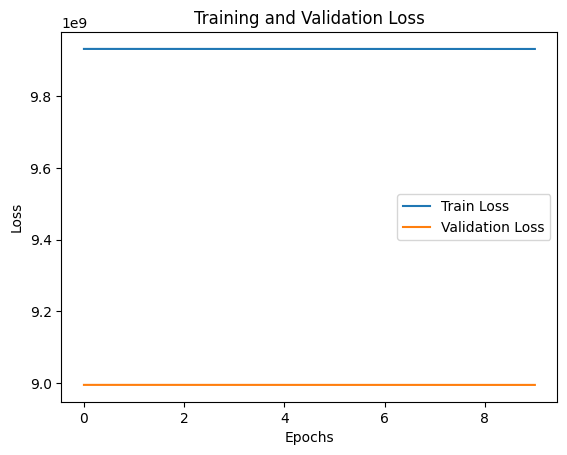

In [651]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

data = {'Education': ['Bachelor', 'Master', 'PhD', 'Bachelor', 'Master'] * 10,
        'Job_Title': ['Software Engineer', 'Data Scientist', 'Machine Learning Engineer', 'Project Manager', 'Business Analyst'] * 10,
        'Gender': ['Male', 'Female', 'Male', 'Female', 'Male'] * 10,
        'Location': ['New York', 'London', 'Paris', 'Tokyo', 'Sydney'] * 10,
        'Salary': [50000, 100000, 150000, 75000, 90000] * 10}

df = pd.DataFrame(data)

# Data Preparation
le = LabelEncoder()
for col in ['Education', 'Job_Title', 'Gender', 'Location']:
    df[col] = le.fit_transform(df[col])

X = df.drop("Salary", axis=1)
y = df["Salary"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Modeling
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Reduced epochs for simulation
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, verbose=1)

# Evaluation
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R2 Score: {r2}")

# Plot Loss Curve
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Save Model

In [652]:
model.save('salary_prediction_model.h5')

from google.colab import files
files.download('salary_prediction_model.h5')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>